# EDA on Titanic
## 1. Load & Understand Data
- Load CSV, basic inspection

In [128]:
#Import libraries
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [129]:
#Import dataset from seaborn 
df = sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [130]:
print(f"rows {df.shape[0]} columns {df.shape[1]} in the dataset")

rows 891 columns 15 in the dataset


In [131]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [132]:
df.dtypes # Checking dtypes so that it is easy to change dataype of a certain column while cleaning or visualizing data

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [133]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [134]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [135]:
df.drop('class', axis=1, inplace=True) #We've encountered redundent columns pclass and class so dropping one column makes sense

In [136]:
df.drop('embarked', axis=1, inplace=True) #We've encountered redundent columns pclass and class so dropping one column makes sense

## Variables Description:
- survived: Survival status of the passenger — 1 = survived, 0 = did not survive
- pclass: Ticket class — 1 = 1st (upper class), 2 = 2nd (middle class), 3 = 3rd (working class)
- sex: Gender of the passenger — male or female
- age: Age of the passenger in years
- sibsp: Number of siblings and/or spouses aboard with the passenger
- parch: Number of parents and/or children aboard with the passenger
- fare: Ticket fare paid by the passenger
- who: Passenger type — man, woman, or child (based on gender and age)
- adult_male: Boolean — True if passenger is an adult male, else False
- deck: Cabin deck — represented by letters like A, B, C, etc.
- embark_town: Port of embarkation — Cherbourg, Queenstown, or Southampton
- alive: Survival status in text form — yes or no
- alone: Boolean — True if passenger had no family aboard, else False

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   who          891 non-null    object  
 8   adult_male   891 non-null    bool    
 9   deck         203 non-null    category
 10  embark_town  889 non-null    object  
 11  alive        891 non-null    object  
 12  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(4)
memory usage: 72.7+ KB


In [138]:
## Getting and visualizaing missing values 

In [139]:
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

Text(0.5, 1.0, 'Heatmap of missing values')

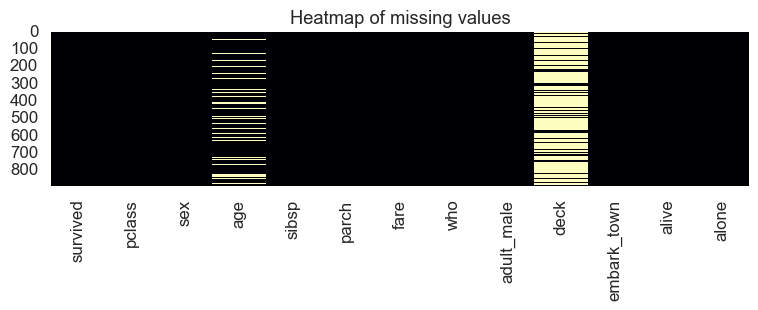

In [140]:
plt.figure(figsize=(9,2))
sns.heatmap(df.isnull(),cmap='magma',cbar=False)
plt.title("Heatmap of missing values")

In [141]:
(df.isnull().mean() * 100).sort_values(ascending=False)
#With tihs we can understand that why the embark_town doesn't not show on heatmap because it has very less number missing values

deck           77.216611
age            19.865320
embark_town     0.224467
survived        0.000000
pclass          0.000000
sex             0.000000
sibsp           0.000000
parch           0.000000
fare            0.000000
who             0.000000
adult_male      0.000000
alive           0.000000
alone           0.000000
dtype: float64

In [142]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'who',
       'adult_male', 'deck', 'embark_town', 'alive', 'alone'],
      dtype='object')

# Basic Data Analysis
- pclass-survived
- sex-survived
- parch-survived
- sibsp survived

In [143]:
df[['survived','pclass']].groupby(['pclass'],as_index=False).mean().sort_values(by='survived',ascending=False)

,pclass,survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [144]:
df[['survived','sex']].groupby(['sex'],as_index=False).mean().sort_values(by='survived',ascending=False)

,sex,survived
0,female,0.742038
1,male,0.188908


In [145]:
df[['survived','parch']].groupby(['parch'],as_index=False).mean().sort_values(by='survived',ascending=False)

,parch,survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


In [146]:
df[['survived','sibsp']].groupby(['sibsp'],as_index=False).mean().sort_values(by='survived',ascending=False)

,sibsp,survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


# Detect Outliers

In [147]:
#Before outliers you can notice the max of the fare column skewed too much 
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Text(0.5, 0, 'Features')

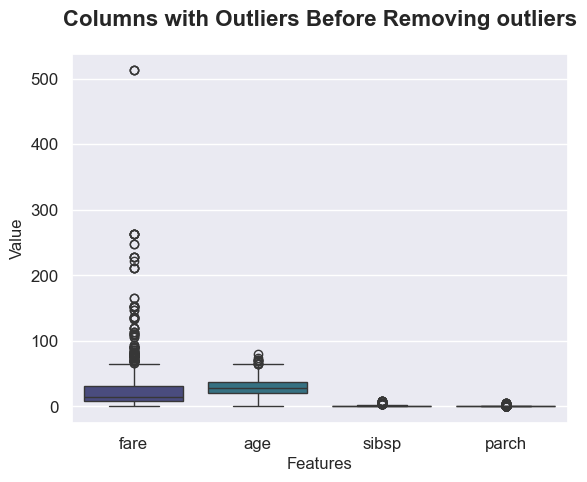

In [148]:
sns.set_style("darkgrid")
sns.boxplot(data=df[['fare','age','sibsp','parch']],palette='viridis')
plt.title("Columns with Outliers Before Removing outliers", fontsize=16, weight='bold', pad=20)
plt.ylabel("Value", fontsize=12)
plt.xlabel("Features", fontsize=12)

In [149]:
from collections import Counter
def detect_outliers(df,col):
    outlier_indices = []
    for c in col:
        #1st Quartile 
        Q1 = np.percentile(df[c],25)
        #3rd Quartile 
        Q3 = np.percentile(df[c],75)
        #Extract IQR 
        IQR = Q3 - Q1 
        outlier_step = IQR * 1.5
        #Detect outlier and their indices
        outlier_list_col = df[(df[c]<Q1-outlier_step) | (df[c]>Q3+outlier_step)].index
        #add outliers indices in the list 
        outlier_indices.extend(outlier_list_col)
    
    outlier_indices = Counter(outlier_indices)
    multiple_outliers = list(i for i, v in outlier_indices.items() if v>=1)
    return multiple_outliers
df.drop(index=detect_outliers(df, ['age', 'fare', 'sibsp', 'parch']), inplace=True)
df.reset_index(drop=True, inplace=True)

In [150]:
#After outliers the max of the fare column came back to normal 
df.describe()
#outliers columns removed

,survived,pclass,age,sibsp,parch,fare
count,607.000000,607.000000,458.00000,607.000000,607.0,607.000000
mean,0.294893,2.462932,31.89083,0.189456,0.0,15.226413
std,0.456371,0.758794,12.61191,0.436027,0.0,12.616712
min,0.000000,1.000000,5.00000,0.000000,0.0,0.000000
25%,0.000000,2.000000,22.00000,0.000000,0.0,7.775000
50%,0.000000,3.000000,29.00000,0.000000,0.0,8.850000
75%,1.000000,3.000000,39.00000,0.000000,0.0,16.750000
max,1.000000,3.000000,80.00000,2.000000,0.0,61.175000


Text(0.5, 0, 'Features')

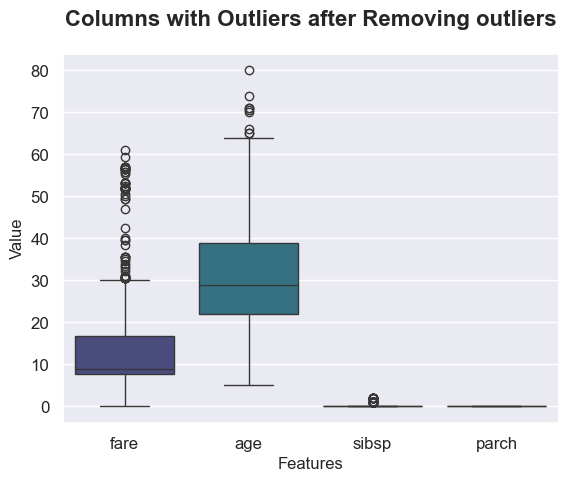

In [151]:
sns.set_style("darkgrid")
sns.boxplot(data=df[['fare','age','sibsp','parch']],palette='viridis')
plt.title("Columns with Outliers after Removing outliers", fontsize=16, weight='bold', pad=20)
plt.ylabel("Value", fontsize=12)
plt.xlabel("Features", fontsize=12)